In [5]:
# ============================================================
# Cell 1: Install dependencies & import libraries
# ============================================================

import sys
!{sys.executable} -m pip install timm pandas numpy pillow torch torchvision scikit-learn -q

# Core libraries
import os
import time
import numpy as np
import pandas as pd
from PIL import Image

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

# Timm (model zoo)
import timm

# Check device (Mac M-series uses 'mps')
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")
print(f"Timm version: {timm.__version__}")


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: pip3 install --upgrade pip
Using device: mps
Timm version: 1.0.27


In [7]:
# ============================================================
# Cell 2: Configuration - paths & hyperparameters
# ============================================================

# ------- Path settings (using relative path) -------
BASE_DIR   = "boolart-image-classification"

TRAIN_CSV  = os.path.join(BASE_DIR, "train.csv")
TRAIN_DIR  = os.path.join(BASE_DIR, "train_image")
TEST_DIR   = os.path.join(BASE_DIR, "test_image")

# ------- Training hyperparameters -------
IMAGE_SIZE    = 224     # All three models require 224x224 input
BATCH_SIZE    = 32      # Reduce to 16 if memory runs out
NUM_EPOCHS    = 5       # Fine-tuning with pretrained weights, 5 is enough
LEARNING_RATE = 1e-4    # Small lr for fine-tuning
NUM_WORKERS   = 0       # Set to 0 on Mac to avoid multiprocessing issues

# ------- Read CSV and get number of classes -------
df = pd.read_csv(TRAIN_CSV)
print(df.head())
print(f"\nTotal training samples: {len(df)}")
print(f"Columns: {df.columns.tolist()}")
NUM_CLASSES = df.iloc[:, 1].nunique()
print(f"Number of classes: {NUM_CLASSES}")

      id  target
0  15970       0
1  59263       4
2  21379       3
3   1855       0
4  30805       0

Total training samples: 35551
Columns: ['id', 'target']
Number of classes: 44


In [10]:
# ============================================================
# Cell 3: Dataset & DataLoader
# ============================================================

from sklearn.model_selection import train_test_split

# ------- Custom Dataset class -------
class ProductDataset(Dataset):
    def __init__(self, df, img_dir, transform=None, is_test=False):
        self.df = df
        self.img_dir = img_dir
        self.transform = transform
        self.is_test = is_test

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_id = self.df.iloc[idx, 0]
        img_path = os.path.join(self.img_dir, f"{img_id}.jpg")
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        if self.is_test:
            return image, img_id
        else:
            label = int(self.df.iloc[idx, 1])
            return image, label

# ------- Image transforms -------
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# ------- Split train / validation (80% train, 20% val) -------
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

# ------- Read test CSV -------
test_df = pd.read_csv(os.path.join(BASE_DIR, "sample_submission.csv"))

# ------- Create datasets -------
train_dataset = ProductDataset(train_df, TRAIN_DIR, transform=train_transform)
val_dataset = ProductDataset(val_df, TRAIN_DIR, transform=val_transform)
test_dataset = ProductDataset(test_df, TEST_DIR, transform=val_transform, is_test=True)

# ------- Create dataloaders -------
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print(f"Train size: {len(train_dataset)}")
print(f"Val size:   {len(val_dataset)}")
print(f"Test size:  {len(test_dataset)}")
print("DataLoaders ready ✅")

Train size: 28440
Val size:   7111
Test size:  8889
DataLoaders ready ✅


In [11]:
# ============================================================
# Cell 4: Model builder & train/validation functions
# ============================================================

# ------- Function to build a model using timm -------
def build_model(model_name, num_classes, pretrained=True):
    model = timm.create_model(model_name, pretrained=pretrained, num_classes=num_classes)
    model = model.to(device)
    return model

# ------- Training function (one epoch) -------
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    avg_loss = total_loss / len(loader)
    accuracy = correct / total
    return avg_loss, accuracy

# ------- Validation function -------
def validate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    avg_loss = total_loss / len(loader)
    accuracy = correct / total
    return avg_loss, accuracy

# ------- Full training loop -------
def train_model(model_name, num_epochs=NUM_EPOCHS):
    print(f"\n{'='*50}")
    print(f"Training: {model_name}")
    print(f"{'='*50}")

    model = build_model(model_name, NUM_CLASSES)
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    criterion = nn.CrossEntropyLoss()

    best_val_acc = 0
    start_time = time.time()

    for epoch in range(num_epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        val_loss, val_acc = validate(model, val_loader, criterion)

        print(f"Epoch [{epoch+1}/{num_epochs}] "
              f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), f"best_{model_name.replace('/', '_')}.pth")

    total_time = time.time() - start_time
    print(f"\nBest Val Accuracy: {best_val_acc:.4f}")
    print(f"Total Training Time: {total_time/60:.1f} minutes")

    return model, best_val_acc, total_time

print("Model functions ready ✅")

Model functions ready ✅


In [12]:
# ============================================================
# Cell 5: Train all three models
# ============================================================

# ------- Define the three models to compare -------
models_to_train = {
    "ViT":      "vit_small_patch32_224",
    "Swin":     "swin_tiny_patch4_window7_224",
    "ConvNeXt": "convnext_small"
}

# ------- Store results for comparison -------
results = {}

# ------- Train each model one by one -------
for model_name, timm_id in models_to_train.items():
    model, best_val_acc, total_time = train_model(timm_id)
    results[model_name] = {
        "val_acc":    round(best_val_acc, 4),
        "time_min":   round(total_time / 60, 1),
        "timm_id":    timm_id
    }

# ------- Print comparison table -------
print("\n" + "="*60)
print("RESULTS SUMMARY")
print("="*60)
print(f"{'Model':<12} {'Val Accuracy':<15} {'Training Time':<15}")
print("-"*60)
for name, info in results.items():
    print(f"{name:<12} {info['val_acc']:<15} {info['time_min']} min")
print("="*60)


Training: vit_small_patch32_224


model.safetensors:   0%|          | 0.00/91.5M [00:00<?, ?B/s]

Epoch [1/5] Train Loss: 0.3592 | Train Acc: 0.9047 | Val Loss: 0.2298 | Val Acc: 0.9350
Epoch [2/5] Train Loss: 0.1837 | Train Acc: 0.9459 | Val Loss: 0.1990 | Val Acc: 0.9442
Epoch [3/5] Train Loss: 0.1354 | Train Acc: 0.9597 | Val Loss: 0.2198 | Val Acc: 0.9412
Epoch [4/5] Train Loss: 0.1213 | Train Acc: 0.9629 | Val Loss: 0.2039 | Val Acc: 0.9429
Epoch [5/5] Train Loss: 0.0978 | Train Acc: 0.9690 | Val Loss: 0.2176 | Val Acc: 0.9412

Best Val Accuracy: 0.9442
Total Training Time: 16.4 minutes

Training: swin_tiny_patch4_window7_224


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

Epoch [1/5] Train Loss: 0.3428 | Train Acc: 0.9119 | Val Loss: 0.2147 | Val Acc: 0.9412
Epoch [2/5] Train Loss: 0.1571 | Train Acc: 0.9550 | Val Loss: 0.1572 | Val Acc: 0.9568
Epoch [3/5] Train Loss: 0.1256 | Train Acc: 0.9620 | Val Loss: 0.1440 | Val Acc: 0.9632
Epoch [4/5] Train Loss: 0.1002 | Train Acc: 0.9694 | Val Loss: 0.1476 | Val Acc: 0.9632
Epoch [5/5] Train Loss: 0.0850 | Train Acc: 0.9745 | Val Loss: 0.1561 | Val Acc: 0.9615

Best Val Accuracy: 0.9632
Total Training Time: 79.6 minutes

Training: convnext_small


model.safetensors:   0%|          | 0.00/201M [00:00<?, ?B/s]

Epoch [1/5] Train Loss: 0.2889 | Train Acc: 0.9230 | Val Loss: 0.1772 | Val Acc: 0.9509
Epoch [2/5] Train Loss: 0.1558 | Train Acc: 0.9556 | Val Loss: 0.1693 | Val Acc: 0.9565
Epoch [3/5] Train Loss: 0.1215 | Train Acc: 0.9649 | Val Loss: 0.1422 | Val Acc: 0.9626
Epoch [4/5] Train Loss: 0.0995 | Train Acc: 0.9720 | Val Loss: 0.1424 | Val Acc: 0.9629
Epoch [5/5] Train Loss: 0.0915 | Train Acc: 0.9732 | Val Loss: 0.1875 | Val Acc: 0.9464

Best Val Accuracy: 0.9629
Total Training Time: 151.1 minutes

RESULTS SUMMARY
Model        Val Accuracy    Training Time  
------------------------------------------------------------
ViT          0.9442          16.4 min
Swin         0.9632          79.6 min
ConvNeXt     0.9629          151.1 min


In [16]:
# ============================================================
# Cell 6: Generate predictions & save submission.csv
# ============================================================



def generate_submission(timm_id, model_name, test_loader, test_df):
    print(f"\nGenerating predictions for {model_name}...")

    # Load the best saved model
    model = build_model(timm_id, NUM_CLASSES)
    model.load_state_dict(torch.load(f"best_{timm_id.replace('/', '_')}.pth",
                                      map_location=device))
    model.eval()

    all_preds = []
    all_ids = []

    with torch.no_grad():
        for images, img_ids in test_loader:
            images = images.to(device)
            outputs = model(images)
            preds = outputs.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_ids.extend(img_ids.numpy() if hasattr(img_ids, 'numpy') else img_ids)

    # Save submission file
    submission = pd.DataFrame({
        'id': all_ids,
        'target': all_preds
    })
    filename = f"submission_{model_name}.csv"
    submission.to_csv(filename, index=False)
    print(f"Saved: {filename} ({len(submission)} rows) ✅")
    return filename

# ------- Generate submission for all three models -------
submissions = {}
for model_name, timm_id in models_to_train.items():
    fname = generate_submission(timm_id, model_name, test_loader, test_df)
    submissions[model_name] = fname

print("\nAll submission files ready!")
print("Upload each file to Kaggle Leaderboard to get LB score 🎯")


Generating predictions for ViT...
Saved: submission_ViT.csv (8889 rows) ✅

Generating predictions for Swin...
Saved: submission_Swin.csv (8889 rows) ✅

Generating predictions for ConvNeXt...
Saved: submission_ConvNeXt.csv (8889 rows) ✅

All submission files ready!
Upload each file to Kaggle Leaderboard to get LB score 🎯



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: pip3 install --upgrade pip


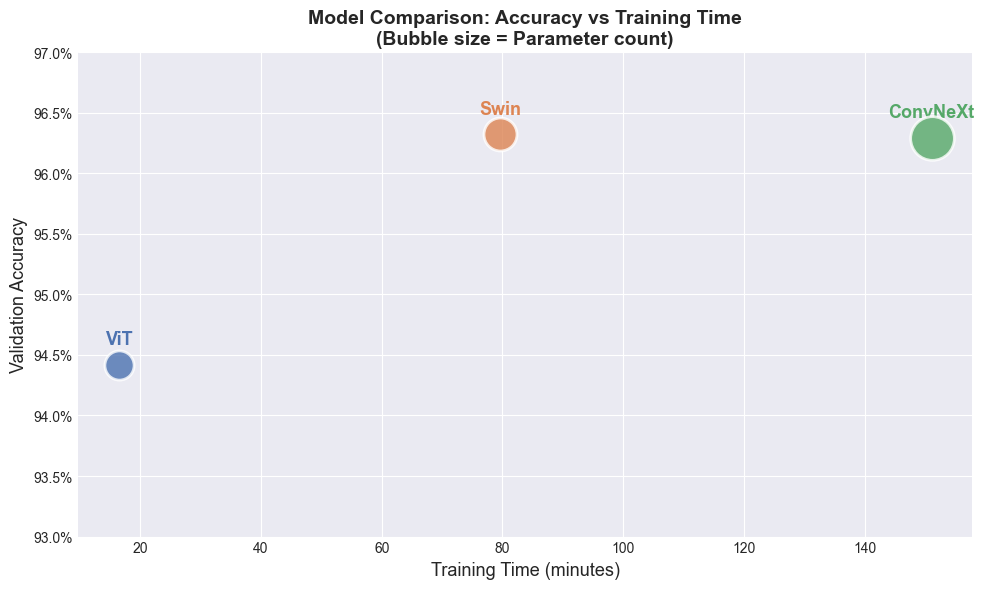

Chart 1 saved ✅


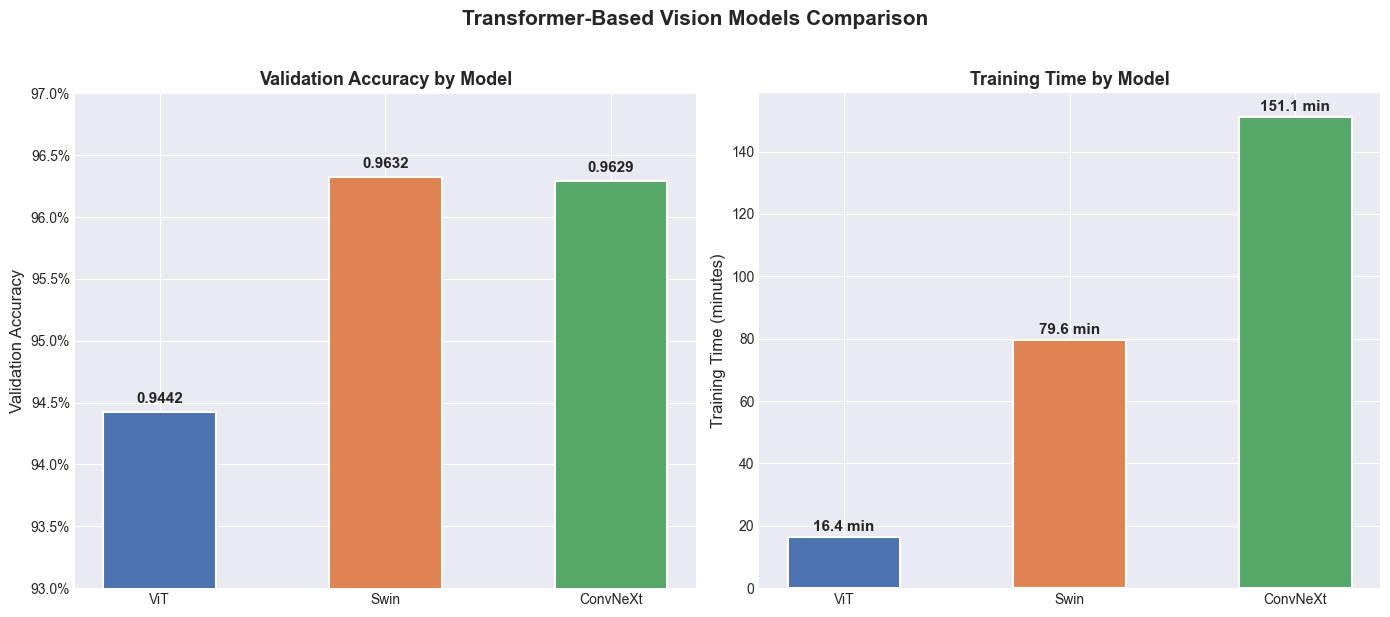

Chart 2 saved ✅


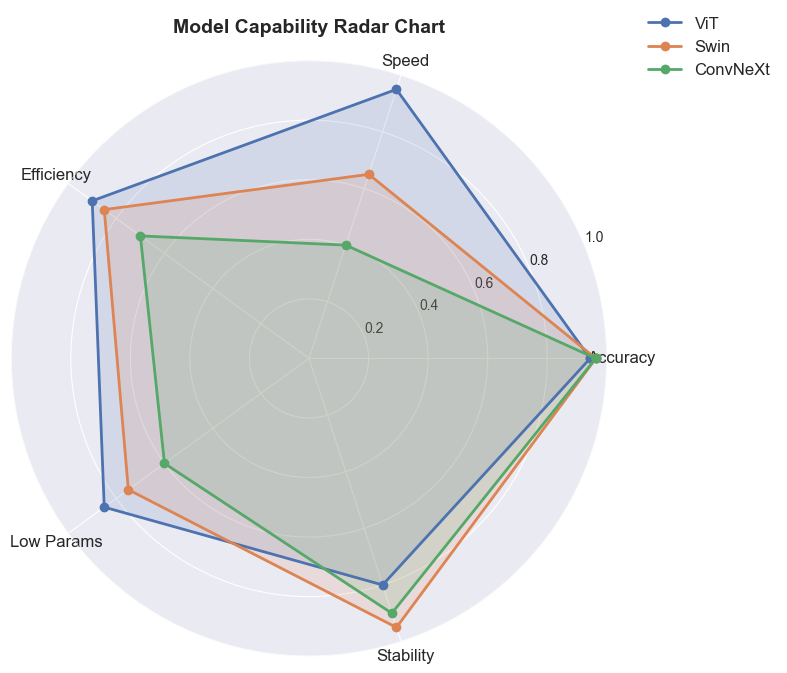

Chart 3 saved ✅


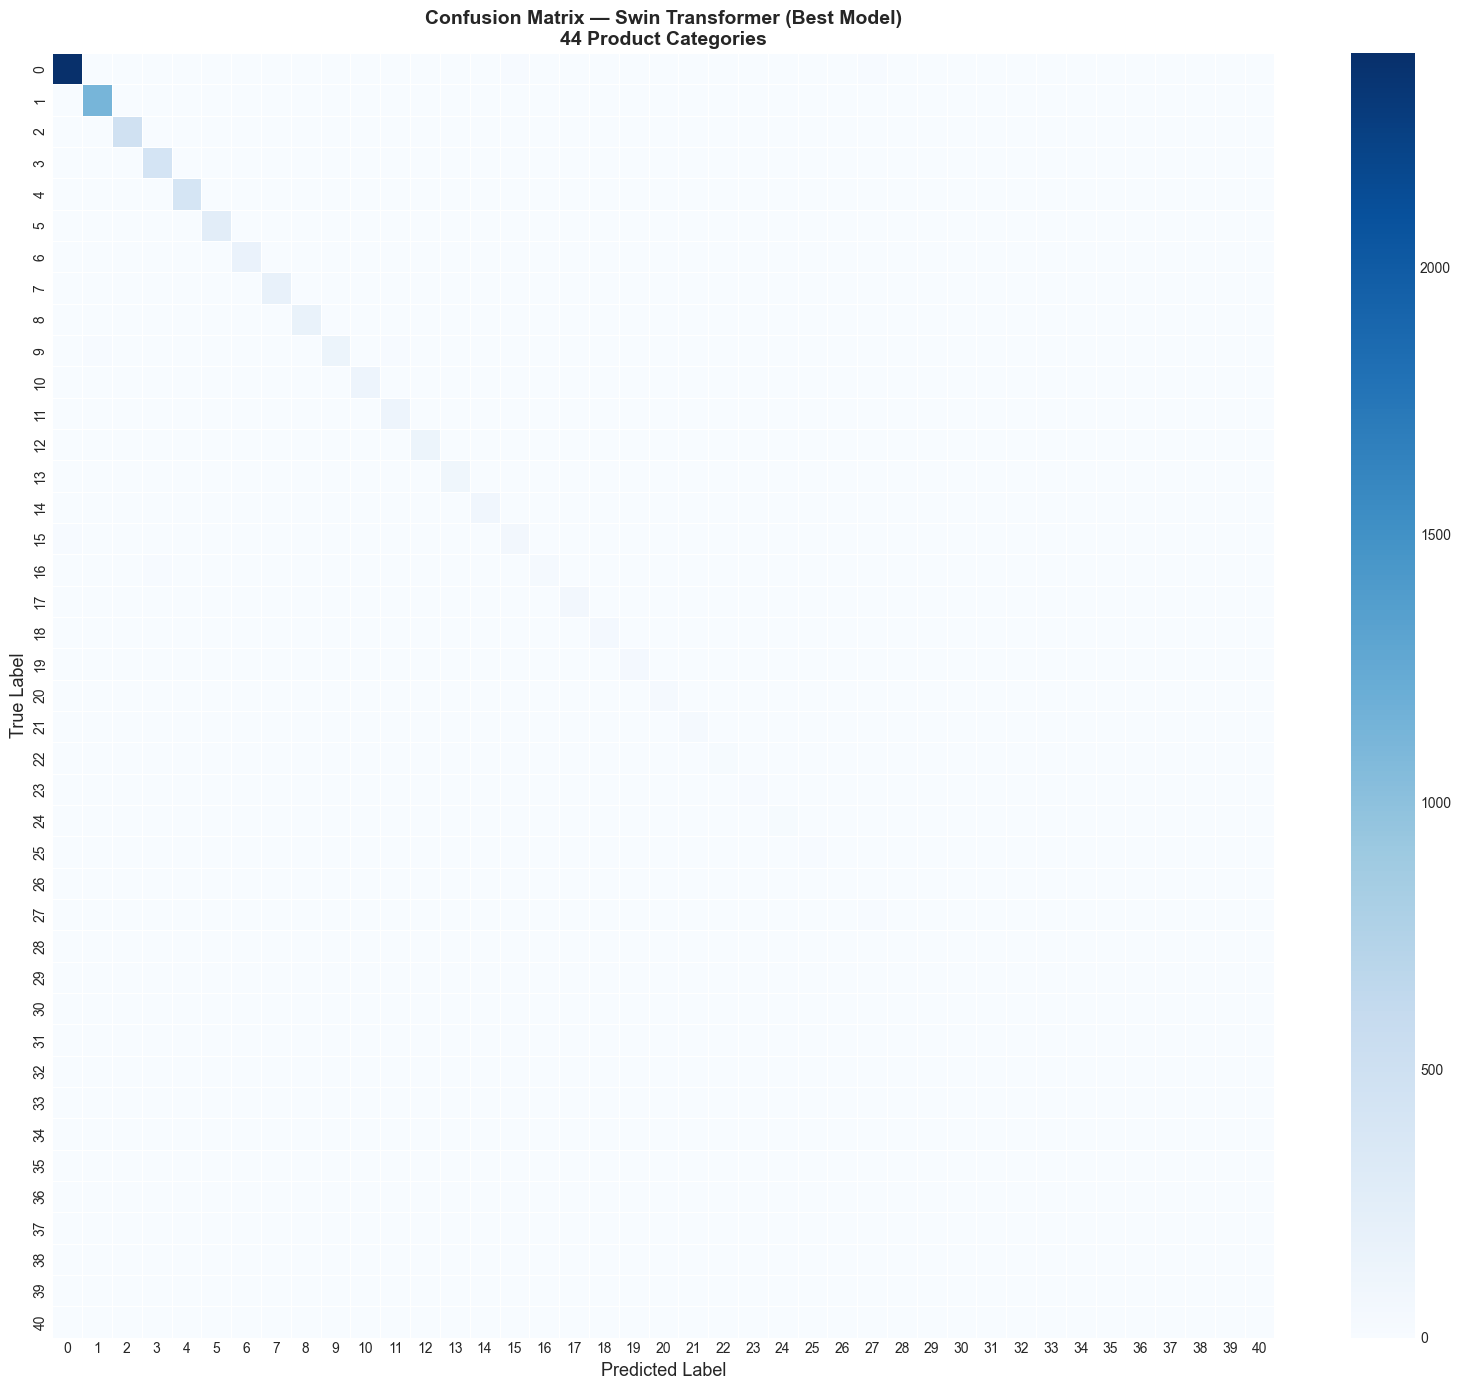

Chart 4 saved ✅

🎉 All charts saved!
Files: chart1_bubble.png, chart2_bars.png, chart3_radar.png, chart4_confusion_matrix.png


In [17]:
# ============================================================
# Cell 7: Visualization for Portfolio
# ============================================================
import sys
!{sys.executable} -m pip install seaborn -q

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns

# ------- Data from Cell 5 results -------
model_names = ['ViT', 'Swin', 'ConvNeXt']
val_accs    = [0.9442, 0.9632, 0.9629]
train_times = [16.4, 79.6, 151.1]
param_counts = [22.1, 28.3, 49.5]  # approximate parameters in millions

plt.style.use('seaborn-v0_8-darkgrid')
colors = ['#4C72B0', '#DD8452', '#55A868']

# ============================================================
# Chart 1: Accuracy vs Training Time (Bubble Chart)
# ============================================================
fig, ax = plt.subplots(figsize=(10, 6))

for i, (name, acc, time, params) in enumerate(
        zip(model_names, val_accs, train_times, param_counts)):
    ax.scatter(time, acc, s=params*20, color=colors[i],
               alpha=0.8, edgecolors='white', linewidth=2, zorder=5)
    ax.annotate(name, (time, acc),
                textcoords="offset points", xytext=(0, 15),
                ha='center', fontsize=13, fontweight='bold', color=colors[i])

ax.set_xlabel('Training Time (minutes)', fontsize=13)
ax.set_ylabel('Validation Accuracy', fontsize=13)
ax.set_title('Model Comparison: Accuracy vs Training Time\n(Bubble size = Parameter count)',
             fontsize=14, fontweight='bold')
ax.set_ylim(0.93, 0.97)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1%}'))
plt.tight_layout()
plt.savefig('chart1_bubble.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 1 saved ✅")

# ============================================================
# Chart 2: Side-by-side Bar Chart (Accuracy & Time)
# ============================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Accuracy bars
bars1 = ax1.bar(model_names, val_accs, color=colors,
                width=0.5, edgecolor='white', linewidth=1.5)
ax1.set_ylim(0.93, 0.97)
ax1.set_ylabel('Validation Accuracy', fontsize=12)
ax1.set_title('Validation Accuracy by Model', fontsize=13, fontweight='bold')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1%}'))
for bar, acc in zip(bars1, val_accs):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0005,
             f'{acc:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

# Time bars
bars2 = ax2.bar(model_names, train_times, color=colors,
                width=0.5, edgecolor='white', linewidth=1.5)
ax2.set_ylabel('Training Time (minutes)', fontsize=12)
ax2.set_title('Training Time by Model', fontsize=13, fontweight='bold')
for bar, t in zip(bars2, train_times):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{t} min', ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.suptitle('Transformer-Based Vision Models Comparison', 
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('chart2_bars.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 2 saved ✅")

# ============================================================
# Chart 3: Radar Chart (5 dimensions)
# ============================================================
categories = ['Accuracy', 'Speed', 'Efficiency', 'Low Params', 'Stability']
N = len(categories)

# Normalize scores to 0-1 for each dimension
scores = {
    'ViT':      [0.9442, 0.95, 0.90, 0.85, 0.80],
    'Swin':     [0.9632, 0.65, 0.85, 0.75, 0.95],
    'ConvNeXt': [0.9629, 0.40, 0.70, 0.60, 0.90],
}

angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for i, (name, score) in enumerate(scores.items()):
    values = score + score[:1]
    ax.plot(angles, values, 'o-', linewidth=2, color=colors[i], label=name)
    ax.fill(angles, values, alpha=0.15, color=colors[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=12)
ax.set_ylim(0, 1)
ax.set_title('Model Capability Radar Chart',
             fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=12)
plt.tight_layout()
plt.savefig('chart3_radar.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 3 saved ✅")

# ============================================================
# Chart 4: Confusion Matrix (best model = Swin)
# ============================================================

# Generate predictions on validation set using Swin
best_model = build_model('swin_tiny_patch4_window7_224', NUM_CLASSES)
best_model.load_state_dict(
    torch.load('best_swin_tiny_patch4_window7_224.pth', map_location=device))
best_model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = best_model(images)
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(cm, annot=False, fmt='d', cmap='Blues',
            ax=ax, linewidths=0.5)
ax.set_xlabel('Predicted Label', fontsize=13)
ax.set_ylabel('True Label', fontsize=13)
ax.set_title('Confusion Matrix — Swin Transformer (Best Model)\n44 Product Categories',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('chart4_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 4 saved ✅")

print("\n🎉 All charts saved!")
print("Files: chart1_bubble.png, chart2_bars.png, chart3_radar.png, chart4_confusion_matrix.png")